In [ ]:
import sys
!{sys.executable} -m pip install requests beautifulsoup4 nltk wordcloud scikit-learn

## Web Scraping de Títulos y Precios de Libros

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# URL de la página a scrapear
url = 'https://books.toscrape.com/'

# Realizar la solicitud HTTP
response = requests.get(url)
response.raise_for_status() # Lanza una excepción para errores HTTP

# Parsear el contenido HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Listas para almacenar los datos
titulos = []
precios = []

# Encontrar todos los artículos de libros
articles = soup.find_all('article', class_='product_pod')

for article in articles:
    # Extraer el título del libro
    title = article.h3.a['title']
    titulos.append(title)

    # Extraer el precio del libro
    price = article.find('p', class_='price_color').text
    # Limpiar el precio: remover el símbolo de moneda y convertir a float
    price = float(price.replace('Â£', '')) # Corrected: '£' changed to 'Â£' to match the actual character in the error
    precios.append(price)

# Crear un DataFrame con los datos
df_libros = pd.DataFrame({
    'titulo': titulos,
    'precio': precios
})

print("DataFrame de libros creado:")
display(df_libros.head())

DataFrame de libros creado:


,titulo,precio
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23


## Procesamiento del Texto y Creación de `datos_limpios`

In [ ]:
import nltk
from nltk.corpus import stopwords
import re

# Descargar las stopwords si no están ya descargadas
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Cargar las stopwords en español e inglés (por si acaso, aunque la página es en inglés)
stop_words = set(stopwords.words('english'))


def limpiar_texto(texto):
    # Pasar todo el texto a minúsculas
    texto = texto.lower()
    # Eliminar números y caracteres especiales (excepto espacios)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    # Remover stopwords
    texto = ' '.join([word for word in texto.split() if word not in stop_words])
    return texto

# Aplicar la función de limpieza al título de los libros
df_libros['titulo_limpio'] = df_libros['titulo'].apply(limpiar_texto)

# Crear el DataFrame datos_limpios
datos_limpios = df_libros[['titulo_limpio', 'precio']]

print("DataFrame 'datos_limpios' creado:")
display(datos_limpios.head())

DataFrame 'datos_limpios' creado:


,titulo_limpio,precio
0,light attic,51.77
1,tipping velvet,53.74
2,soumission,50.10
3,sharp objects,47.82
4,sapiens brief history humankind,54.23


## Generación de N-gramas, Frecuencias y Nube de Palabras

DataFrame 'count' (n-gramas y frecuencias) creado:


,n_grama,frecuencia
0,life,3
1,little,2
2,scott,2
3,attic,1
4,light,1
5,soumission,1
6,velvet,1
7,tipping,1
8,sapiens,1
9,history,1


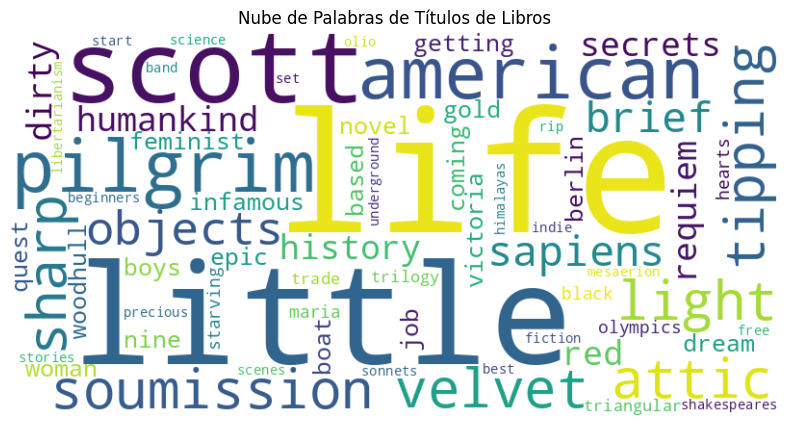


Interpretación de la Nube de Palabras:
La nube de palabras visualiza los términos más frecuentes en los títulos de los libros después de la limpieza. Las palabras más grandes y con colores más intensos son las que aparecen con mayor recurrencia. Esto nos da una idea rápida de los temas o categorías predominantes en esta colección de libros, como por ejemplo, si hay muchas palabras relacionadas con 'love', 'story', 'girl', etc., lo cual indicaría una prevalencia de ciertos géneros.


In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todos los títulos limpios en un solo string
texto_completo = ' '.join(datos_limpios['titulo_limpio'])

# Generar n-gramas (en este caso, 1-gramas o palabras individuales) y contar su frecuencia
# Si se desearan n-gramas de mayor longitud, se podría usar CountVectorizer con ngram_range
palabras = texto_completo.split()
conteo_ngramas = Counter(palabras)

# Crear el DataFrame 'count'
count = pd.DataFrame(conteo_ngramas.items(), columns=['n_grama', 'frecuencia'])
count = count.sort_values(by='frecuencia', ascending=False).reset_index(drop=True)

print("DataFrame 'count' (n-gramas y frecuencias) creado:")
display(count.head(10))

# Crear la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(texto_completo)

# Visualizar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Títulos de Libros')
plt.show()

# Interpretación de la nube de palabras
print("\nInterpretación de la Nube de Palabras:\nLa nube de palabras visualiza los términos más frecuentes en los títulos de los libros después de la limpieza. Las palabras más grandes y con colores más intensos son las que aparecen con mayor recurrencia. Esto nos da una idea rápida de los temas o categorías predominantes en esta colección de libros, como por ejemplo, si hay muchas palabras relacionadas con 'love', 'story', 'girl', etc., lo cual indicaría una prevalencia de ciertos géneros.")

## Matriz de Frecuencia de Términos (TF) y Análisis por Palabras Seleccionadas

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Crear una instancia de CountVectorizer para la matriz TF
# Excluimos las palabras que ya fueron removidas en la limpieza
vectorizer = CountVectorizer()

# Ajustar y transformar los títulos limpios en una matriz TF
X = vectorizer.fit_transform(datos_limpios['titulo_limpio'])

# Obtener los nombres de las características (palabras)
feature_names = vectorizer.get_feature_names_out()

# Crear el DataFrame de la matriz TF
df_tf = pd.DataFrame(X.toarray(), columns=feature_names)

# Añadir la columna de precio del libro a la matriz TF
df_tf['precio'] = datos_limpios['precio']

print("Matriz de Term Frequency (TF) creada con precios:")
display(df_tf.head())

Matriz de Term Frequency (TF) creada con precios:


,american,americans,attic,band,based,beginners,berlin,best,black,boat,...,tipping,trade,triangular,trilogy,underground,velvet,victoria,woman,woodhull,precio
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,51.77
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,53.74
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,50.10
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,47.82
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,54.23


In [ ]:
# Elegir 10 palabras del corpus para el análisis. Se pueden seleccionar las más frecuentes del DataFrame 'count'.
palabras_seleccionadas = count['n_grama'].head(10).tolist()

# Crear un DataFrame para el análisis de las palabras seleccionadas
df_palabras_analisis = df_tf[palabras_seleccionadas].copy()

# Reemplazar la frecuencia por 1 si aparece más de una vez o 0 si no aparece
for col in palabras_seleccionadas:
    df_palabras_analisis[col] = (df_palabras_analisis[col] > 0).astype(int)

# Añadir la columna de precio a este DataFrame
df_palabras_analisis['precio'] = df_tf['precio']

print("DataFrame con palabras seleccionadas y binarias:")
display(df_palabras_analisis.head())

# Calcular el precio promedio de los libros cuando estas palabras aparecen (1) y cuando no (0)
resultados_analisis = pd.DataFrame()

for palabra in palabras_seleccionadas:
    precio_si_aparece = df_palabras_analisis[df_palabras_analisis[palabra] == 1]['precio'].mean()
    precio_no_aparece = df_palabras_analisis[df_palabras_analisis[palabra] == 0]['precio'].mean()

    resultados_analisis = pd.concat([
        resultados_analisis,
        pd.DataFrame({
            'palabra': [palabra, palabra],
            'aparicion': [1, 0],
            'precio_promedio': [precio_si_aparece, precio_no_aparece]
        })
    ], ignore_index=True)

print("Resultados del análisis de precio promedio por palabra:")
display(resultados_analisis)

DataFrame con palabras seleccionadas y binarias:


,life,little,scott,attic,light,soumission,velvet,tipping,sapiens,history,precio
0,0,0,0,1,1,0,0,0,0,0,51.77
1,0,0,0,0,0,0,1,1,0,0,53.74
2,0,0,0,0,0,1,0,0,0,0,50.10
3,0,0,0,0,0,0,0,0,0,0,47.82
4,0,0,0,0,0,0,0,0,1,1,54.23


Resultados del análisis de precio promedio por palabra:


,palabra,aparicion,precio_promedio
0,life,1,42.490000
1,life,0,37.264706
2,little,1,42.815000
3,little,0,37.518889
4,scott,1,52.290000
5,scott,0,37.298947
6,attic,1,51.770000
7,attic,0,37.326316
8,light,1,51.770000
9,light,0,37.326316


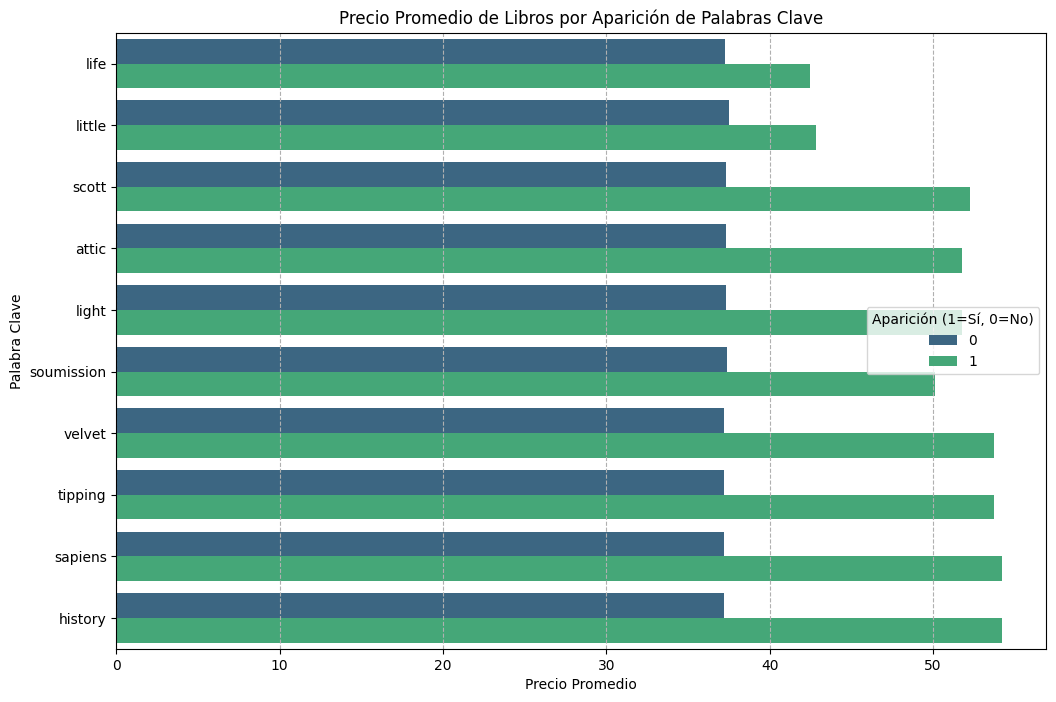


Interpretación de la Gráfica:
Esta gráfica de barras compara el precio promedio de los libros cuando una palabra específica está presente (Aparición=1) versus cuando no lo está (Aparición=0) en el título. Podemos observar si ciertas palabras están asociadas con precios más altos o más bajos. Si la barra azul (Aparición=1) es significativamente más larga que la barra verde (Aparición=0) para una palabra, esto sugiere una asociación positiva entre la presencia de esa palabra y un precio de libro más alto. Por el contrario, si la barra azul es más corta, la asociación sería negativa. Esto puede ofrecer insights sobre qué tipo de temática o género podría ser percibido como de mayor o menor valor en el mercado de libros scrappeado.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.barplot(data=resultados_analisis, x='precio_promedio', y='palabra', hue='aparicion', palette='viridis')
plt.title('Precio Promedio de Libros por Aparición de Palabras Clave')
plt.xlabel('Precio Promedio')
plt.ylabel('Palabra Clave')
plt.legend(title='Aparición (1=Sí, 0=No)', loc='center right')
plt.grid(axis='x', linestyle='--')
plt.show()

print("\nInterpretación de la Gráfica:\nEsta gráfica de barras compara el precio promedio de los libros cuando una palabra específica está presente (Aparición=1) versus cuando no lo está (Aparición=0) en el título. Podemos observar si ciertas palabras están asociadas con precios más altos o más bajos. Si la barra azul (Aparición=1) es significativamente más larga que la barra verde (Aparición=0) para una palabra, esto sugiere una asociación positiva entre la presencia de esa palabra y un precio de libro más alto. Por el contrario, si la barra azul es más corta, la asociación sería negativa. Esto puede ofrecer insights sobre qué tipo de temática o género podría ser percibido como de mayor o menor valor en el mercado de libros scrappeado.")